In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

files = {
    "NativeVM": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/native.csv",
    "NativeVM2": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/native2.csv",
    "NativeVM3": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/native3.csv",
    "NativeVM4": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/native4.csv",
    #"SEVVM": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/sev.csv",
    #"SEVVM2": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/sev2.csv"

}
#CSV format:
#Matrix,Cores,Run,Type,Iteration,Runtime,Gflops
all_data = []
for name, path in files.items():
    df = pd.read_csv(path,index_col=False)
    df['Environment'] = name 
    all_data.append(df)

df = pd.concat(all_data, ignore_index=True)
df_iter=df[df['Type'] == 'ITER']
df_io=df[df['Type'] == 'IO_LOAD']

In [9]:
run_means = df_iter.groupby(['Environment', 'Run'])['Gflops'].mean().reset_index()

batch_stats = run_means.groupby('Environment')['Gflops'].agg(['mean', 'std', 'count'])

print("--- Analyse der Binary-Runs (Ebene 2) ---")
print(batch_stats)

# 3. Differenz der Batches vs. Schwankung innerhalb der Batches
diff_batches = abs(batch_stats.loc['NativeVM', 'mean'] - batch_stats.loc['NativeVM2', 'mean'])
pooled_std = np.sqrt((batch_stats.loc['NativeVM', 'std']**2 + batch_stats.loc['NativeVM2', 'std']**2) / 2)

print("\n--- Vergleich der Bash-Skript-Starts (Ebene 1) ---")
print(f"Unterschied zwischen den Skript-Starts: {diff_batches:.6f} Gflops")
print(f"Typische Schwankung zwischen Runs:      {pooled_std:.6f} Gflops")

if diff_batches > pooled_std:
    print("\nERGEBNIS: Der Skript-Neustart hat einen messbaren Einfluss.")
else:
    print("\nERGEBNIS: Der Skript-Neustart liegt im Bereich des normalen Rauschens.")

--- Analyse der Binary-Runs (Ebene 2) ---
                 mean       std  count
Environment                           
NativeVM     3.225952  0.004648     10
NativeVM2    3.218862  0.007154     10

--- Vergleich der Bash-Skript-Starts (Ebene 1) ---
Unterschied zwischen den Skript-Starts: 0.007090 Gflops
Typische Schwankung zwischen Runs:      0.006033 Gflops

ERGEBNIS: Der Skript-Neustart hat einen messbaren Einfluss.


<Axes: xlabel='Iteration', ylabel='Gflops'>

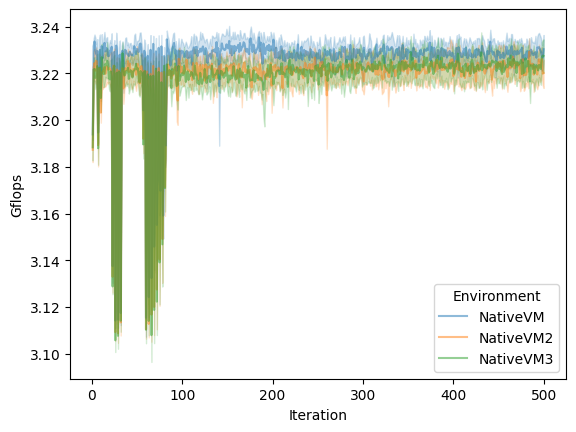

In [12]:
sns.lineplot(data=df_iter, x='Iteration', y='Gflops', hue='Environment',alpha=0.5)

<Axes: xlabel='Run', ylabel='Runtime'>

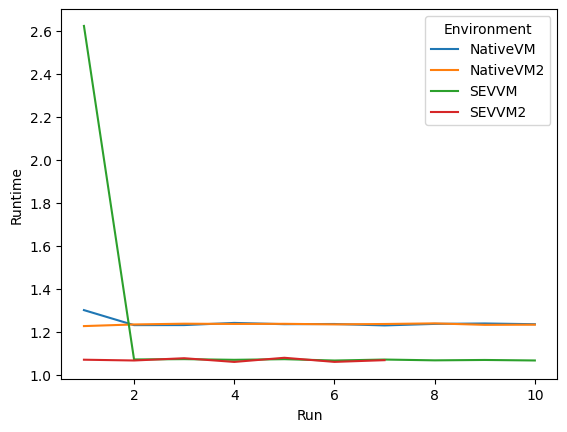

In [67]:
sns.lineplot(data=df_io, x='Run', y='Runtime', hue='Environment')